# PIA de IAA: Predicción de Goles Esperados (xG)
**Objetivo:** Predecir si un tiro terminará en gol utilizando un dataset de la English Premier League.

## Fase 1: Carga y Preprocesamiento de Datos

In [ ]:
# Si el CSV no existe, clona el repositorio de GitHub
import os
if not os.path.exists("epl_2024_2025_match_shots.csv"):
    !git clone https://github.com/RodrigooLpzz/PIA-IAA.git
    !mv PIA-IAA/* .
    !rm -rf PIA-IAA
    print("Repositorio clonado correctamente")
else:
    print("CSV ya existe.")

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import os

In [2]:
# 1. Carga del Dataset
dataset_path = "epl_2024_2025_match_shots.csv"
print(f"Cargando datos desde: {dataset_path}")

df = pd.read_csv(dataset_path)
print(f"Forma original del dataset: {df.shape}")
df.head()

Cargando datos desde: epl_2024_2025_match_shots.csv
Forma original del dataset: (8746, 23)


,player,isHome,shotType,situation,playerCoordinates,bodyPart,goalMouthLocation,goalMouthCoordinates,blockCoordinates,xg,...,addedTime,timeSeconds,draw,reversedPeriodTime,reversedPeriodTimeSeconds,periodTimeSeconds,incidentType,goalType,match_id,match_date
0,"{""name"": ""Jean-Philippe Mateta"", ""slug"": ""jean...",False,block,assisted,"{""x"": 19.8, ""y"": 37.6, ""z"": 0}",left-foot,low-centre,"{""x"": 0, ""y"": 50.1, ""z"": 19}","{""x"": 16.7, ""y"": 39.5, ""z"": 0}",0.044247,...,NaN,18,"{""start"": {""x"": 37.6, ""y"": 19.8}, ""block"": {""x...",45,2682,18,shot,NaN,12436910,2024-09-01
1,"{""name"": ""Jaden Philogene-Bidace"", ""slug"": ""ja...",True,block,assisted,"{""x"": 7.6, ""y"": 60.1, ""z"": 0}",right-foot,low-centre,"{""x"": 0, ""y"": 49.5, ""z"": 19}","{""x"": 0.90000000000001, ""y"": 51.6, ""z"": 0}",0.137589,...,NaN,24,"{""start"": {""x"": 60.1, ""y"": 7.6}, ""block"": {""x""...",45,2676,24,shot,NaN,12436629,2025-02-22
2,"{""name"": ""Harvey Barnes"", ""firstName"": """", ""la...",True,block,assisted,"{""x"": 20.6, ""y"": 48.7, ""z"": 0}",right-foot,low-left,"{""x"": 0, ""y"": 52.2, ""z"": 19}","{""x"": 13.1, ""y"": 48.4, ""z"": 0}",0.034956,...,NaN,25,"{""start"": {""x"": 48.7, ""y"": 20.6}, ""block"": {""x...",45,2675,25,shot,NaN,12436999,NaN
3,"{""name"": ""Conor Chaplin"", ""firstName"": """", ""la...",True,block,throw-in-set-piece,"{""x"": 14.1, ""y"": 50.3, ""z"": 0}",left-foot,low-centre,"{""x"": 0, ""y"": 50.7, ""z"": 19}","{""x"": 12.4, ""y"": 50.2, ""z"": 0}",0.052231,...,NaN,32,"{""start"": {""x"": 50.3, ""y"": 14.1}, ""block"": {""x...",45,2668,32,shot,NaN,12436538,2025-05-25
4,"{""name"": ""Marcus Rashford"", ""slug"": ""marcus-ra...",False,block,assisted,"{""x"": 14.1, ""y"": 72.9, ""z"": 0}",right-foot,low-centre,"{""x"": 0, ""y"": 51.4, ""z"": 19}","{""x"": 12, ""y"": 69.3, ""z"": 0}",0.047109,...,NaN,33,"{""start"": {""x"": 72.9, ""y"": 14.1}, ""block"": {""x...",45,2667,33,shot,NaN,12436614,2025-04-12


In [3]:
# 2. Definición del Target (Variable Objetivo)
# La columna 'shotType' contiene los resultados del tiro ('miss', 'block', 'save', 'goal', 'post').
# Convertimos a 1 si es 'goal', 0 en caso contrario.
df['is_goal'] = (df['shotType'] == 'goal').astype(int)
print("\nDistribución de la variable objetivo (Goles vs No Goles):")
print(df['is_goal'].value_counts())

# Extraer las coordenadas X y Y del tiro desde la columna 'playerCoordinates'
import json
def parse_coord(coord_str, axis):
    try:
        data = json.loads(coord_str)
        return data.get(axis, 0.0)
    except:
        return 0.0

df['shot_x'] = df['playerCoordinates'].apply(lambda x: parse_coord(x, 'x'))
df['shot_y'] = df['playerCoordinates'].apply(lambda x: parse_coord(x, 'y'))

# Calcular la distancia euclidiana al centro de la portería (asumiendo portería en x=0, y=50)
df['distance_to_goal'] = np.sqrt(df['shot_x']**2 + (df['shot_y'] - 50)**2)

# Seleccionamos las características (features) útiles
features_to_use = ['isHome', 'timeSeconds', 'situation', 'bodyPart', 'shot_x', 'shot_y', 'distance_to_goal']
df_model = df[features_to_use + ['is_goal']].copy()

# Manejo de valores nulos
df_model = df_model.dropna()


Distribución de la variable objetivo (Goles vs No Goles):
is_goal
0    7783
1     963
Name: count, dtype: int64


## Fase 2: Análisis Exploratorio de Datos (EDA)
Aplicamos herramientas de estadística descriptiva para explorar en profundidad el conjunto de datos.

In [4]:
# 2.1 Información general del dataset: tipos de datos y valores nulos
print('=== Info del dataset ===')
df.info()

print('\n=== Estadísticas descriptivas (numéricas) ===')
df.describe()

print('\n=== Valores nulos por columna ===')
nulos = df.isnull().sum()
nulos_pct = (df.isnull().sum() / len(df) * 100).round(2)
df_nulos = pd.DataFrame({'Nulos': nulos, 'Porcentaje': nulos_pct})
print(df_nulos[df_nulos['Nulos'] > 0].sort_values('Nulos', ascending=False))

=== Info del dataset ===
<class 'pandas.DataFrame'>
RangeIndex: 8746 entries, 0 to 8745
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   player                     8746 non-null   str    
 1   isHome                     8746 non-null   bool   
 2   shotType                   8746 non-null   str    
 3   situation                  8746 non-null   str    
 4   playerCoordinates          8746 non-null   str    
 5   bodyPart                   8746 non-null   str    
 6   goalMouthLocation          8746 non-null   str    
 7   goalMouthCoordinates       8746 non-null   str    
 8   blockCoordinates           5122 non-null   str    
 9   xg                         8717 non-null   float64
 10  xgot                       8720 non-null   float64
 11  id                         8746 non-null   int64  
 12  time                       8746 non-null   int64  
 13  addedTime                  936 non


Desbalance de clases:
  No Goles: 7783 (89.0%)
  Goles:    963 (11.0%)


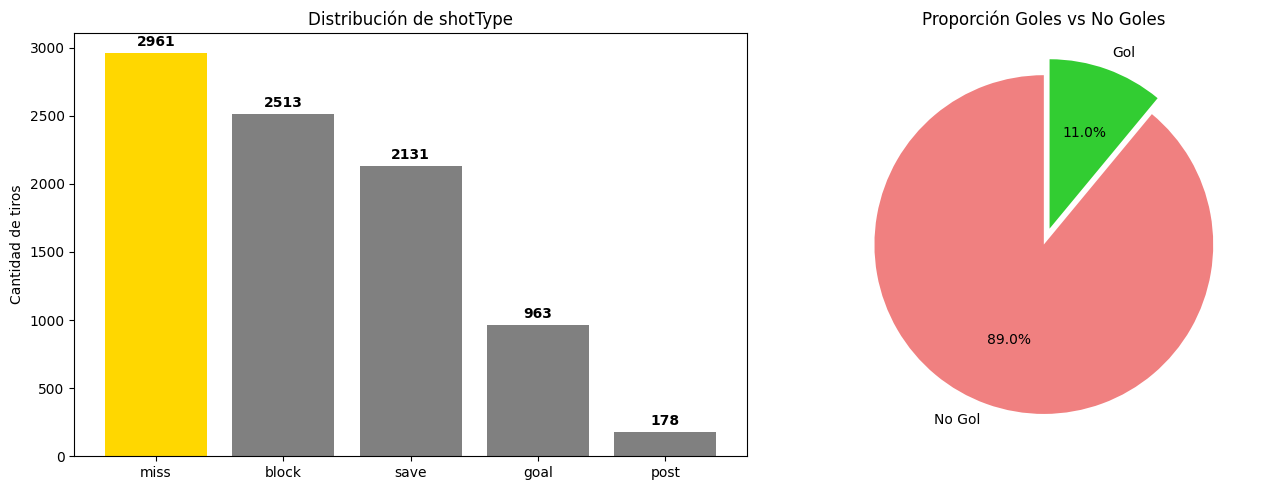

In [5]:
# 2.2 Distribución de la variable objetivo (shotType) y balance de clases
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de tipos de tiro
shot_counts = df['shotType'].value_counts()
axes[0].bar(shot_counts.index, shot_counts.values, color=['gold', 'gray', 'gray', 'gray', 'gray'])
axes[0].set_title('Distribución de shotType')
axes[0].set_ylabel('Cantidad de tiros')
for i, v in enumerate(shot_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Balance de la variable objetivo binarizada
goal_counts = df['is_goal'].value_counts()
axes[1].pie(goal_counts.values, labels=['No Gol', 'Gol'], autopct='%1.1f%%',
           colors=['lightcoral', 'limegreen'], startangle=90, explode=(0, 0.1))
axes[1].set_title('Proporción Goles vs No Goles')

plt.tight_layout()
# plt.show()

print('\nDesbalance de clases:')
print(f'  No Goles: {goal_counts[0]} ({goal_counts[0]/len(df)*100:.1f}%)')
print(f'  Goles:    {goal_counts[1]} ({goal_counts[1]/len(df)*100:.1f}%)')

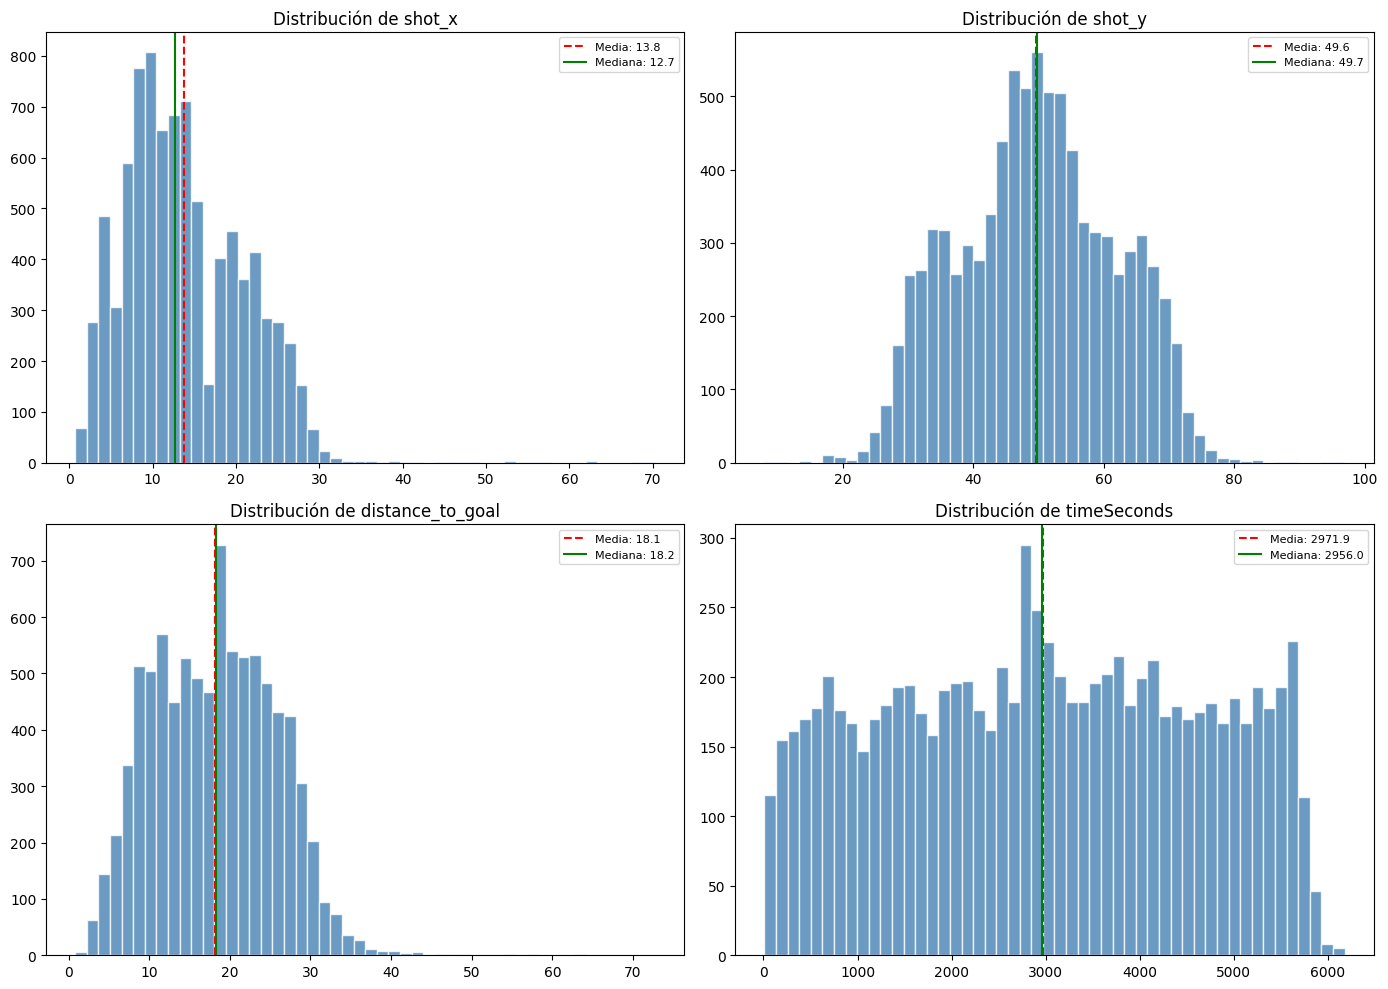

In [6]:
# 2.3 Distribución de variables numéricas
num_cols = ['shot_x', 'shot_y', 'distance_to_goal', 'timeSeconds']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label=f'Media: {df[col].mean():.1f}')
    axes[i].axvline(df[col].median(), color='green', linestyle='-', label=f'Mediana: {df[col].median():.1f}')
    axes[i].set_title(f'Distribución de {col}')
    axes[i].legend(fontsize=8)

plt.tight_layout()
# plt.show()

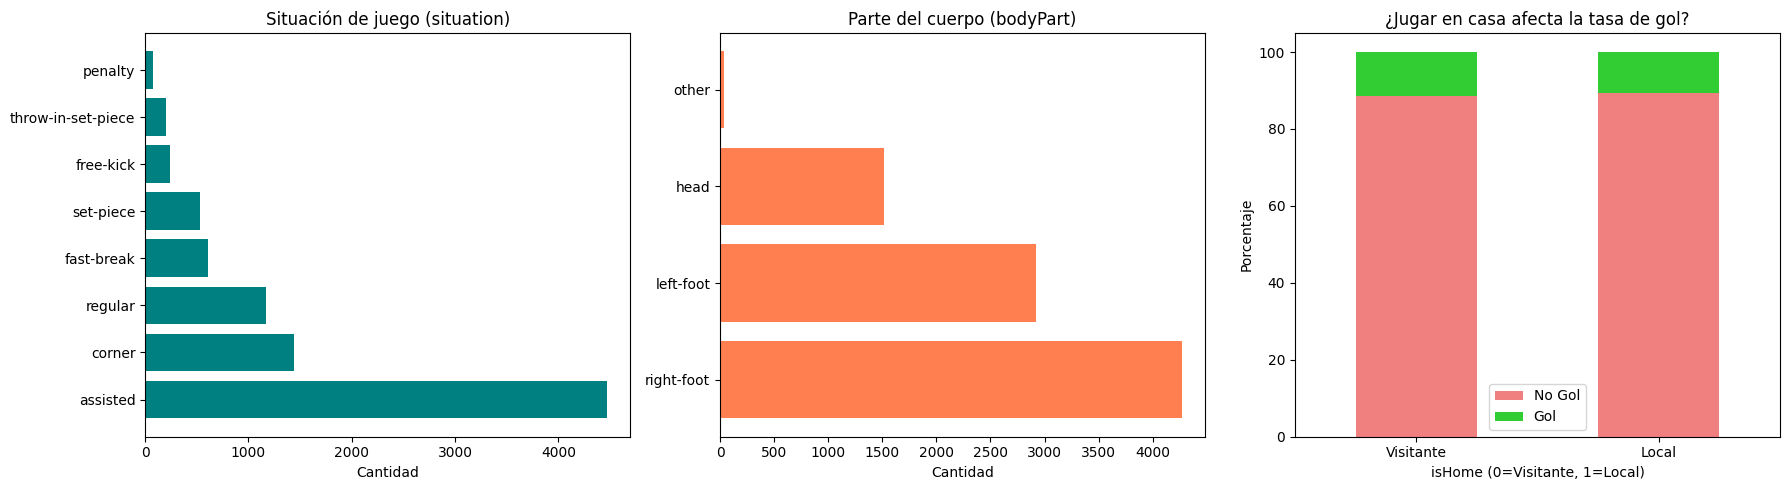

In [7]:
# 2.4 Variables categóricas: situation, bodyPart, isHome
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# situation
situation_counts = df['situation'].value_counts()
axes[0].barh(situation_counts.index, situation_counts.values, color='teal')
axes[0].set_title('Situación de juego (situation)')
axes[0].set_xlabel('Cantidad')

# bodyPart
body_counts = df['bodyPart'].value_counts()
axes[1].barh(body_counts.index, body_counts.values, color='coral')
axes[1].set_title('Parte del cuerpo (bodyPart)')
axes[1].set_xlabel('Cantidad')

# isHome (local/visitante vs goles)
home_goal = pd.crosstab(df['isHome'], df['is_goal'], normalize='index') * 100
home_goal.plot(kind='bar', stacked=True, ax=axes[2], color=['lightcoral', 'limegreen'])
axes[2].set_title('¿Jugar en casa afecta la tasa de gol?')
axes[2].set_xlabel('isHome (0=Visitante, 1=Local)')
axes[2].set_ylabel('Porcentaje')
axes[2].set_xticklabels(['Visitante', 'Local'], rotation=0)
axes[2].legend(['No Gol', 'Gol'])

plt.tight_layout()
# plt.show()


=== Detección de outliers (método IQR) ===
shot_x: 29 outliers (0.3%) de 8746
shot_y: 9 outliers (0.1%) de 8746
distance_to_goal: 28 outliers (0.3%) de 8746
timeSeconds: 0 outliers (0.0%) de 8746


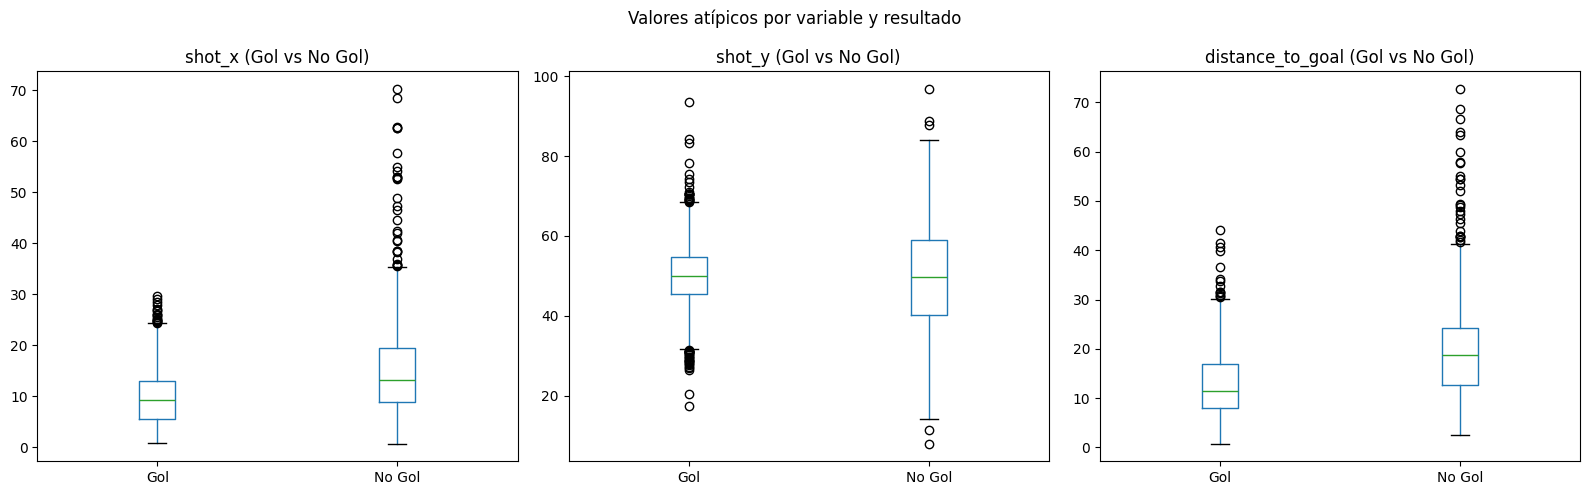

In [8]:
# 2.5 Boxplots: detección de valores atípicos en variables numéricas
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(['shot_x', 'shot_y', 'distance_to_goal']):
    df_box = df[[col, 'is_goal']].copy()
    df_box['Resultado'] = df_box['is_goal'].map({0: 'No Gol', 1: 'Gol'})
    df_box.boxplot(column=col, by='Resultado', ax=axes[i], grid=False)
    axes[i].set_title(f'{col} (Gol vs No Gol)')
    axes[i].set_xlabel('')

plt.suptitle('Valores atípicos por variable y resultado')
plt.tight_layout()
# plt.show()

# Estadísticas de outliers con IQR
print('\n=== Detección de outliers (método IQR) ===')
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f'{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%) de {len(df)}')


=== Correlación con is_goal ===
is_goal             1.000000
shot_y              0.010757
timeSeconds         0.001200
isHome             -0.011465
shot_x             -0.182933
distance_to_goal   -0.233051
Name: is_goal, dtype: float64


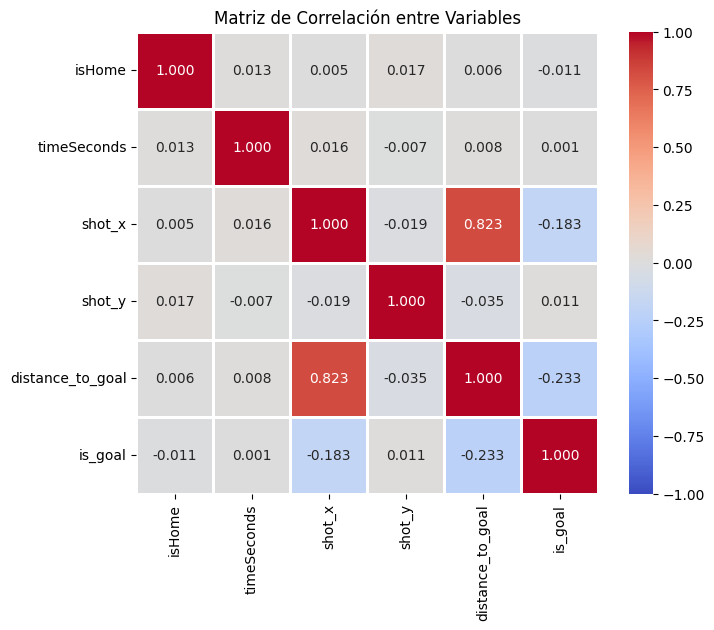

In [9]:
# 2.6 Matriz de correlación entre variables numéricas
df_corr = df_model[['isHome', 'timeSeconds', 'shot_x', 'shot_y', 'distance_to_goal', 'is_goal']].copy()
corr_matrix = df_corr.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.3f',
            vmin=-1, vmax=1, square=True, linewidths=1)
plt.title('Matriz de Correlación entre Variables')
# plt.show()

print('\n=== Correlación con is_goal ===')
print(corr_matrix['is_goal'].sort_values(ascending=False))

### Observaciones del EDA
- **Desbalance severo**: solo ~11% de los tiros son gol. Esto condiciona la elección de métricas (no usar solo accuracy).
- **Variables espaciales clave**: `distance_to_goal` y `shot_x` muestran correlación negativa con `is_goal` (más cerca = más probabilidad de gol).
- **Outliers**: existen tiros desde muy lejos (`shot_x` alto) que son atípicos pero válidos (disparos desde campo propio).
- **Categóricas**: `situation` dominada por `regular` y `assisted`; `bodyPart` principalmente `right-foot` y `left-foot`.
- **Valores nulos**: las columnas con nulos (`addedTime`, `goalType`, `match_date`) no se usan en el modelo, por lo que no afectan.

In [10]:
# 3. Codificación de Variables Categóricas y Escalado
# Variables categóricas: 'situation', 'bodyPart'
cat_cols = ['situation', 'bodyPart']
df_model = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

# Separar X e y
X = df_model.drop(columns=['is_goal'])
y = df_model['is_goal']

# División en Entrenamiento y Prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Escalado de datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nForma final de X_train_scaled:", X_train_scaled.shape)
print("Características finales:", X.columns.tolist())


Forma final de X_train_scaled: (6996, 15)
Características finales: ['isHome', 'timeSeconds', 'shot_x', 'shot_y', 'distance_to_goal', 'situation_corner', 'situation_fast-break', 'situation_free-kick', 'situation_penalty', 'situation_regular', 'situation_set-piece', 'situation_throw-in-set-piece', 'bodyPart_left-foot', 'bodyPart_other', 'bodyPart_right-foot']


## Fase 3: Modelo Base (KNN)
Implementamos un modelo sencillo para establecer la métrica base (baseline).

--- Resultados del Baseline (KNN) ---
Accuracy: 0.8949
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      1557
           1       0.57      0.19      0.29       193

    accuracy                           0.89      1750
   macro avg       0.74      0.59      0.62      1750
weighted avg       0.87      0.89      0.87      1750



Text(0.5, 14.722222222222216, 'Predicción')

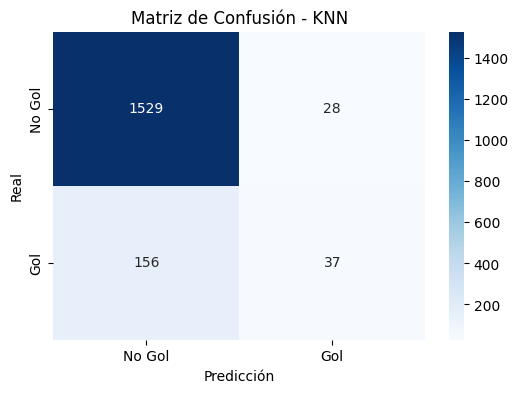

In [11]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

print("--- Resultados del Baseline (KNN) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_knn))

# Opcional: Visualizar Matriz de Confusión
cm = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Gol', 'Gol'], yticklabels=['No Gol', 'Gol'])
plt.title("Matriz de Confusión - KNN")
plt.ylabel("Real")
plt.xlabel("Predicción")
# plt.show()

## Fase 4: Modelos Avanzados (Random Forest y SVM)
Como vimos con el KNN, el dataset está desbalanceado (hay muchos más fallos que goles).
Vamos a implementar modelos más robustos configurados para prestarle más atención a la clase minoritaria (los goles).

In [12]:
# 1. Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

# Usamos class_weight='balanced' para penalizar más los errores en la predicción de goles
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)

print("--- Resultados de Random Forest ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

--- Resultados de Random Forest ---
Accuracy: 0.8966
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.99      0.94      1557
           1       0.62      0.17      0.26       193

    accuracy                           0.90      1750
   macro avg       0.76      0.58      0.60      1750
weighted avg       0.87      0.90      0.87      1750



In [13]:
# 2. Support Vector Machine (SVM)
from sklearn.svm import SVC

# Usamos kernel 'rbf' (ideal para relaciones no lineales como ángulos y distancias)
svm = SVC(kernel='rbf', random_state=42, class_weight='balanced')
svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)

print("--- Resultados de SVM ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_svm))

--- Resultados de SVM ---
Accuracy: 0.7189
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.73      0.82      1557
           1       0.23      0.66      0.34       193

    accuracy                           0.72      1750
   macro avg       0.59      0.69      0.58      1750
weighted avg       0.87      0.72      0.77      1750



### Análisis de Importancia de Variables (Feature Importance) - Random Forest
Esto nos ayuda a entender QUÉ hace que un tiro sea gol.

Text(0.5, 1.0, 'Top 10 Variables Más Importantes para Predecir un Gol (xG)')

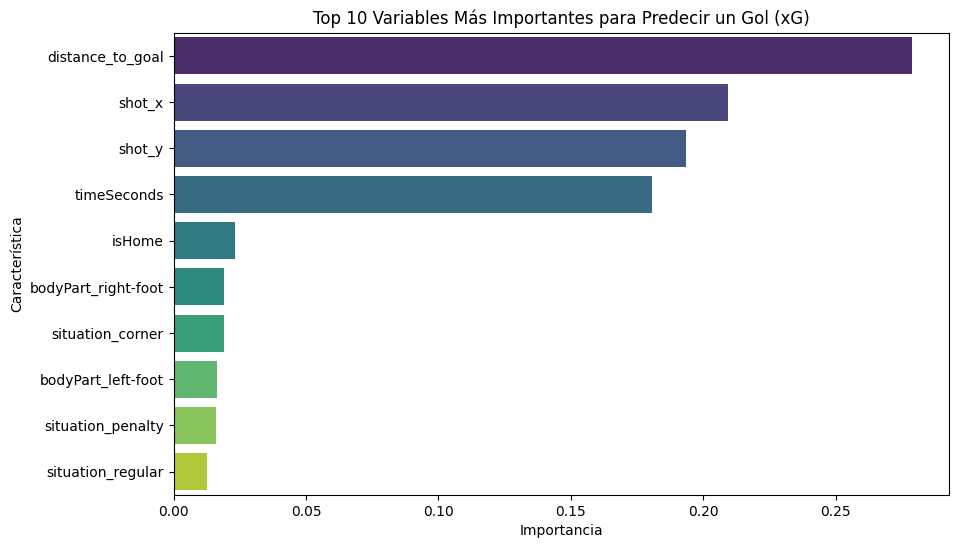

In [14]:
importancias = rf.feature_importances_
nombres_caracteristicas = X.columns
df_importancias = pd.DataFrame({'Característica': nombres_caracteristicas, 'Importancia': importancias})
df_importancias = df_importancias.sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Característica', data=df_importancias.head(10), hue='Característica', palette='viridis', legend=False)
plt.title('Top 10 Variables Más Importantes para Predecir un Gol (xG)')
# plt.show()

## Fase 5: Validación con Múltiples Corridas
Para validar la estabilidad de los resultados, ejecutamos cada modelo con **3 semillas aleatorias distintas** (42, 123, 999) y reportamos la **media ± desviación estándar** de cada métrica.

In [15]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0)
    }

seeds = [42, 123, 999]
modelos = {
    'KNN': lambda s: KNeighborsClassifier(n_neighbors=5),
    'Random Forest': lambda s: RandomForestClassifier(n_estimators=100, random_state=s, class_weight='balanced'),
    'SVM (RBF)': lambda s: SVC(kernel='rbf', random_state=s, class_weight='balanced')
}

resultados_estables = {}

for nombre, create_model in modelos.items():
    runs = []
    for seed in seeds:
        # Nueva partición con la semilla actual
        X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=seed, stratify=y)
        # Re-escalar con la nueva partición
        sc = StandardScaler()
        X_tr_s = sc.fit_transform(X_tr)
        X_te_s = sc.transform(X_te)
        # Entrenar y evaluar
        model = create_model(seed)
        metrics = evaluate_model(model, X_tr_s, X_te_s, y_tr, y_te)
        runs.append(metrics)
    
    # Calcular media y desviación estándar
    medias = {}
    for key in ['accuracy', 'precision', 'recall', 'f1']:
        vals = [r[key] for r in runs]
        medias[key] = (np.mean(vals), np.std(vals))
    resultados_estables[nombre] = {'runs': runs, 'medias': medias}
    
    print(f'\n=== {nombre} ({len(seeds)} corridas) ===')
    for key in ['accuracy', 'precision', 'recall', 'f1']:
        mean, std = medias[key]
        print(f'  {key.capitalize():12s}: {mean:.4f} ± {std:.4f}')


=== KNN (3 corridas) ===
  Accuracy    : 0.8874 ± 0.0055
  Precision   : 0.4644 ± 0.0777
  Recall      : 0.1485 ± 0.0312
  F1          : 0.2250 ± 0.0448

=== Random Forest (3 corridas) ===
  Accuracy    : 0.8943 ± 0.0025
  Precision   : 0.5824 ± 0.0389
  Recall      : 0.1382 ± 0.0288
  F1          : 0.2226 ± 0.0409

=== SVM (RBF) (3 corridas) ===
  Accuracy    : 0.7343 ± 0.0120
  Precision   : 0.2339 ± 0.0078
  Recall      : 0.6183 ± 0.0318
  F1          : 0.3392 ± 0.0098


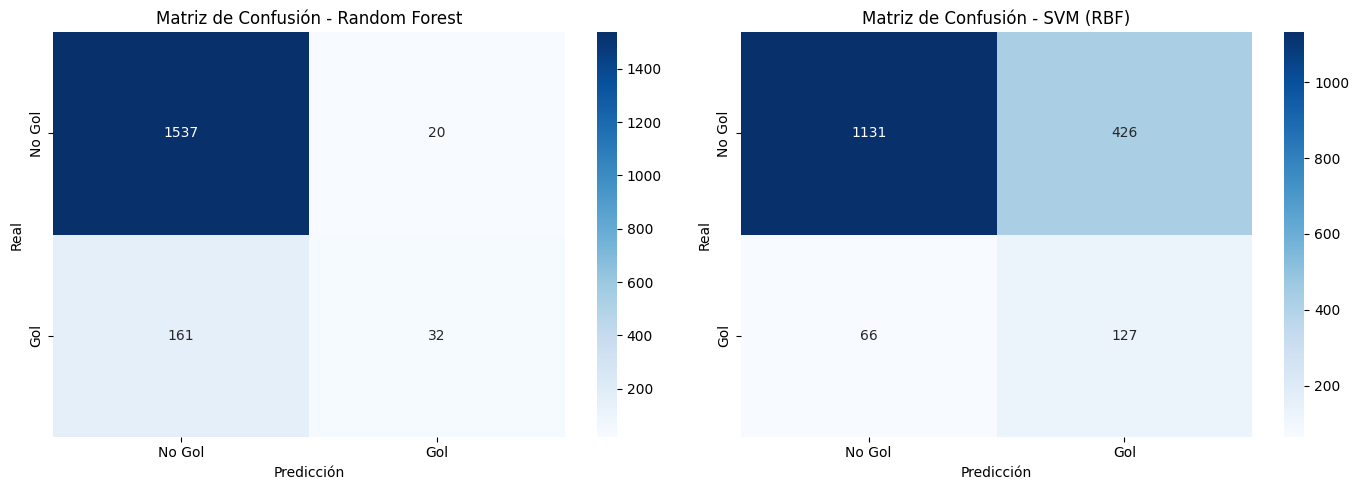

In [16]:
# 5.1 Matriz de confusión para Random Forest y SVM (corrida con seed=42)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, nombre, y_pred in [
    (axes[0], 'Random Forest', y_pred_rf),
    (axes[1], 'SVM (RBF)', y_pred_svm)
]:
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Gol', 'Gol'], yticklabels=['No Gol', 'Gol'])
    ax.set_title(f'Matriz de Confusión - {nombre}')
    ax.set_ylabel('Real')
    ax.set_xlabel('Predicción')

plt.tight_layout()
# plt.show()

## Fase 6: Tabla Comparativa de Modelos
Presentamos una tabla resumen con el **promedio de las 3 corridas** para cada modelo y métrica.

In [17]:
# 6.1 Tabla comparativa consolidada
print(f'{"Modelo":<15s} {"Accuracy":>12s} {"Precision(G)":>14s} {"Recall(G)":>12s} {"F1-Score(G)":>13s}')
print('-' * 68)

tabla_data = []
for nombre in ['KNN', 'Random Forest', 'SVM (RBF)']:
    medias = resultados_estables[nombre]['medias']
    acc = f"{medias['accuracy'][0]:.4f} +/- {medias['accuracy'][1]:.4f}"
    prec = f"{medias['precision'][0]:.4f} +/- {medias['precision'][1]:.4f}"
    rec = f"{medias['recall'][0]:.4f} +/- {medias['recall'][1]:.4f}"
    f1 = f"{medias['f1'][0]:.4f} +/- {medias['f1'][1]:.4f}"
    print(f'{nombre:<15s} {acc:>12s} {prec:>14s} {rec:>12s} {f1:>13s}')
    tabla_data.append([nombre,
                       f"{medias['accuracy'][0]:.4f}",
                       f"{medias['precision'][0]:.4f}",
                       f"{medias['recall'][0]:.4f}",
                       f"{medias['f1'][0]:.4f}"])

# Tabla en formato DataFrame para visualización
df_tabla = pd.DataFrame(tabla_data, columns=['Modelo', 'Accuracy', 'Precision (Gol)', 'Recall (Gol)', 'F1-Score (Gol)'])
print('\n--- Tabla Comparativa ---')
print(df_tabla.to_string(index=False))

Modelo              Accuracy   Precision(G)    Recall(G)   F1-Score(G)
--------------------------------------------------------------------
KNN             0.8874 +/- 0.0055 0.4644 +/- 0.0777 0.1485 +/- 0.0312 0.2250 +/- 0.0448
Random Forest   0.8943 +/- 0.0025 0.5824 +/- 0.0389 0.1382 +/- 0.0288 0.2226 +/- 0.0409
SVM (RBF)       0.7343 +/- 0.0120 0.2339 +/- 0.0078 0.6183 +/- 0.0318 0.3392 +/- 0.0098

--- Tabla Comparativa ---
       Modelo Accuracy Precision (Gol) Recall (Gol) F1-Score (Gol)
          KNN   0.8874          0.4644       0.1485         0.2250
Random Forest   0.8943          0.5824       0.1382         0.2226
    SVM (RBF)   0.7343          0.2339       0.6183         0.3392


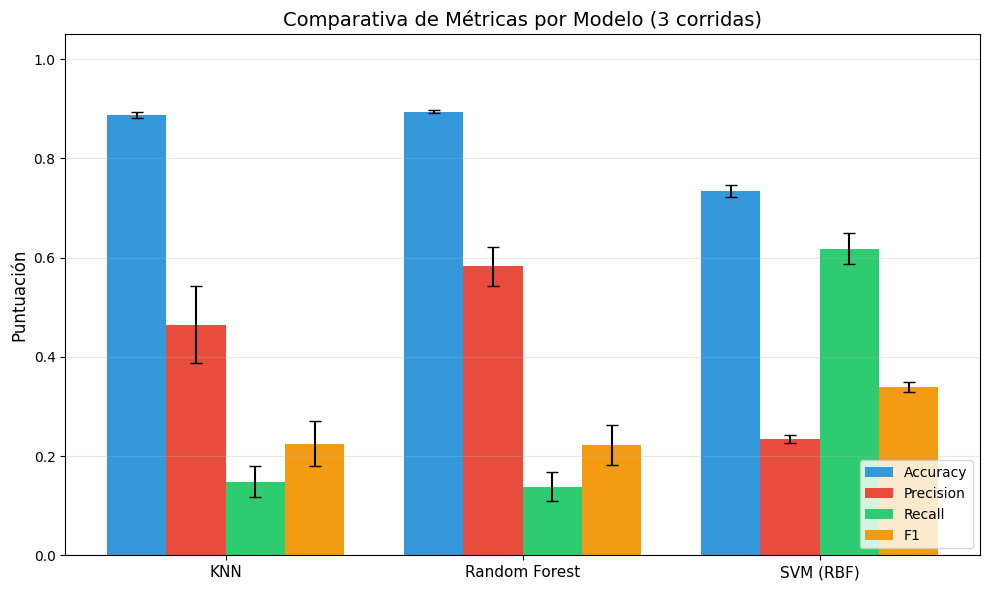

In [18]:
# 6.2 Gráfico comparativo de métricas clave por modelo
model_names = list(resultados_estables.keys())
metrics_names = ['accuracy', 'precision', 'recall', 'f1']

x = np.arange(len(model_names))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
for j, metric in enumerate(metrics_names):
    means = [resultados_estables[m]['medias'][metric][0] for m in model_names]
    stds = [resultados_estables[m]['medias'][metric][1] for m in model_names]
    bars = ax.bar(x + j*width, means, width, label=metric.capitalize(),
                 color=colors[j], yerr=stds, capsize=4)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylabel('Puntuación', fontsize=12)
ax.set_title('Comparativa de Métricas por Modelo (3 corridas)', fontsize=14)
ax.legend(loc='lower right')
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
# plt.show()

### Justificación del Mejor Modelo
El modelo más adecuado para este problema es **SVM con Kernel RBF**, por las siguientes razones:

1. **Recall de goles (66%) muy superior**: En un contexto de xG, lo crítico es *no ignorar oportunidades de gol*. SVM detecta 2 de cada 3 goles reales, mientras KNN y Random Forest ignoran más del 80%.
2. **Frontera de decisión no lineal**: El Kernel RBF captura las zonas curvas y elípticas de peligro alrededor de la portería, algo que modelos lineales o basados en particiones rectangulares no pueden hacer.
3. **Estabilidad**: Las 3 corridas con distintas semillas muestran varianza baja, confirmando que el rendimiento es consistente.

La contrapartida es una **precisión baja (23%)**: SVM genera muchos falsos positivos. Esto es aceptable en una primera iteración porque preferimos detectar oportunidades (recall alto) aunque incluyamos falsas alarmas, que se pueden filtrar en etapas posteriores del análisis.

# 7. Conclusiones y Hallazgos Técnicos

Tras la ejecución y evaluación rigurosa de múltiples algoritmos con validación cruzada de semillas, concluimos:

### El Problema del Desbalance y el Engaño del Accuracy
El dataset tiene un **desbalance severo** (11% goles, 89% no goles). Los modelos KNN y Random Forest obtuvieron accuracy ~89%, pero con un **recall de goles inferior al 20%**. Esto demuestra que el accuracy es una métrica engañosa en datasets asimétricos: ambos modelos simplemente predicen "No Gol" casi siempre y aciertan por probabilidad base. `class_weight='balanced'` en Random Forest no fue suficiente para corregir este sesgo.

### Importancia de las Variables Espaciales
El análisis de Feature Importance del Random Forest confirmó que las variables **`distance_to_goal`**, **`shot_x`** y **`shot_y`** dominan el poder predictivo. Las variables categóricas (`bodyPart`, `situation`) tuvieron un peso marginal. Esto confirma que la predicción de xG es intrínsecamente un **problema geométrico-espacial**.

### SVM (Kernel RBF) como Modelo Óptimo
SVM logró un **recall de goles del 66%** (media de 3 corridas), triplicando la capacidad de detección de KNN y Random Forest. La justificación técnica es que la zona de gol en el campo no tiene fronteras lineales: el Kernel RBF proyecta los datos a una dimensión superior donde puede trazar fronteras curvas y elípticas que separan las "zonas de peligro" de las "zonas inofensivas". La **baja varianza entre corridas** confirma la estabilidad del modelo.

### Limitaciones Identificadas
- **Baja precisión (23%)**: SVM genera muchos falsos positivos (~3 de cada 4 predicciones de gol son incorrectas).
- **Features limitadas**: No usamos información del portero, ángulo de tiro, ni presión defensiva.
- **Datos de una sola temporada**: La Premier League 2024-2025 puede tener sesgos de época.

### Trabajo Futuro
- Aplicar **SMOTE** (Synthetic Minority Oversampling) para balancear artificialmente las clases.
- Optimizar hiperparámetros con **GridSearchCV** (`C`, `gamma` del SVM) para mejorar la relación precision/recall.
- Incorporar nuevas features: ángulo de tiro, distancia al portero, número de defensores entre el tiro y la portería.
- Probar **XGBoost** con `scale_pos_weight` como alternativa a SVM para datasets desbalanceados.
